In [1]:
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt  # 绘图
import pandas as pd
from sklearn.datasets import load_iris  # 从sklearn导入iris数据集

# 加载iris数据集
iris = load_iris()

# 将数据集转换为pandas DataFrame
# 特征数据
dataset = pd.DataFrame(data=iris.data, columns=iris.feature_names)
# 添加目标列（类别）
dataset['Class'] = [iris.target_names[i] for i in iris.target]

# 将特征列名改为与之前一致的格式（使用下划线）
dataset.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'Class']

print(dataset.shape)  # 打印数据集形状
dataset.head()  # 默认读取前5行


(150, 5)


,sepal_length,sepal_width,petal_length,petal_width,Class
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [2]:
# 提取单个特征列
dataset['sepal_length']

0      5.1
1      4.9
2      4.7
3      4.6
4      5.0
      ... 
145    6.7
146    6.3
147    6.5
148    6.2
149    5.9
Name: sepal_length, Length: 150, dtype: float64

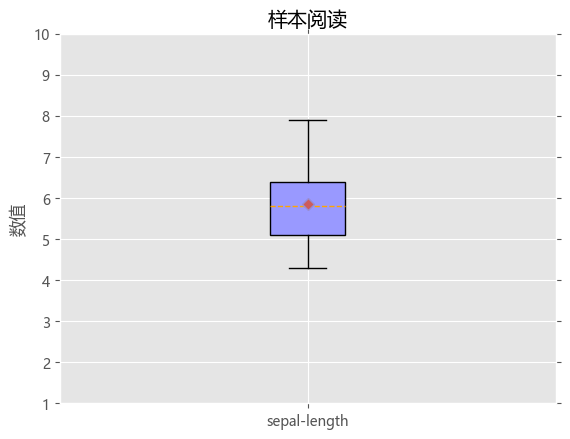

In [3]:
# 绘制BOX图，可视化分析数据
import matplotlib.pyplot as plt
import matplotlib as mpl

# 设置图形显示风格
plt.style.use('ggplot')
# 设置中文和负号正常显示
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

plt.boxplot(
    x=dataset['sepal_length'],  # 指定绘图数据
    patch_artist=True,  # 允许自定义颜色填充盒形图
    showmeans=True,  # 以点的形式显示均值
    boxprops={'color': 'black', 'facecolor': '#9999ff'},  # 箱体属性（边框色、填充色）
    flierprops={'marker': 'o', 'markerfacecolor': 'red', 'color': 'black'},  # 异常值属性（形状、填充色、边框色）
    meanprops={'marker': 'D', 'markerfacecolor': 'indianred'},  # 均值点属性（形状、填充色）
    medianprops={'linestyle': '--', 'color': 'orange'}  # 中位数线属性（线型、颜色）
)

# 设置y轴范围
plt.ylim(1, 10)

# 去除箱线图的上、右边框刻度标签
plt.tick_params(top='off', right='off')
plt.xticks([1], ['sepal-length'])
plt.ylabel("数值")
plt.title("样本阅读")
# 显示图形
plt.show()

C:\Users\21626\AppData\Local\Temp\ipykernel_23664\1346736097.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


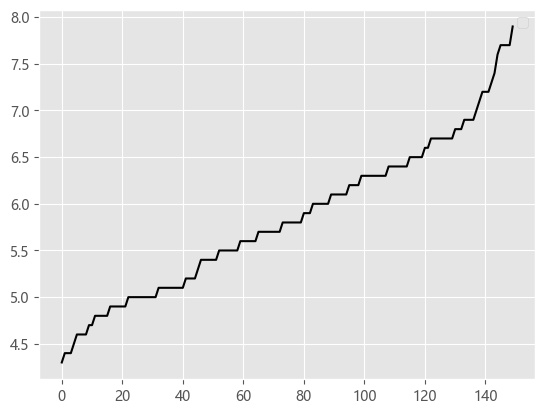

In [4]:
# 曲线图
plt.plot(range(len(dataset['sepal_length'])), sorted(dataset['sepal_length']), c="black")
plt.legend()
plt.show()

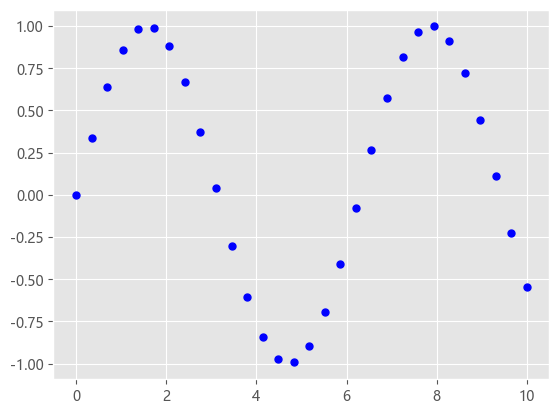

In [5]:
# 简单散点图
x = np.linspace(0, 10, 30)
y = np.sin(x)
plt.plot(x, y, 'bo', ms=5)

Text(0, 0.5, 'sepal width (cm)')

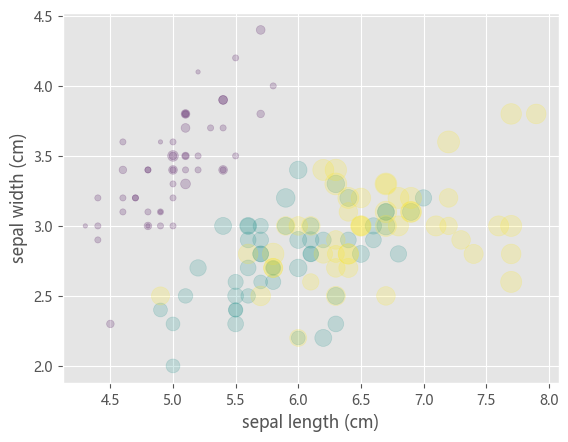

In [6]:
# 鸢尾花数据集散点图
from sklearn.datasets import load_iris
iris = load_iris()
features = iris.data.T
plt.scatter(
    features[0], 
    features[1], 
    alpha=0.2,  # 透明度
    s=100 * features[3],  # 点大小（由花瓣宽度决定）
    c=iris.target  # 颜色映射（由目标类别决定）
)
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])

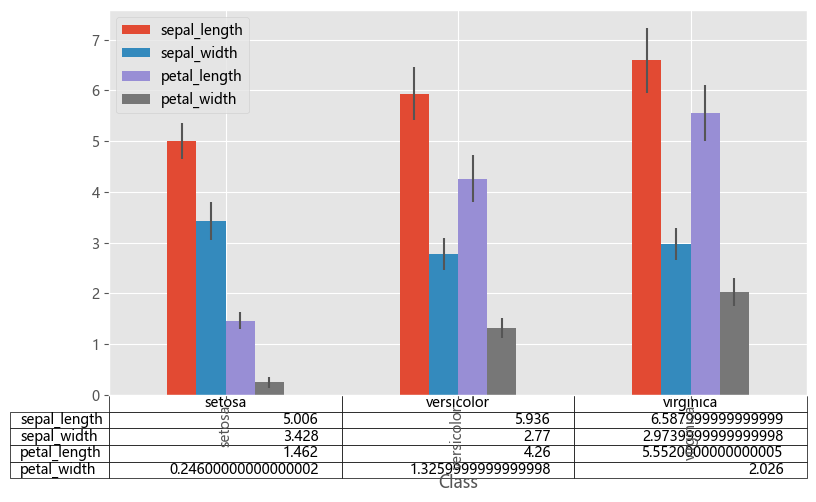

In [7]:
# 按类别分组的均值±标准差条形图
groups = dataset.groupby(by="Class")
means, sds = groups.mean(), groups.std()
means.plot(
    yerr=sds, 
    kind='bar', 
    figsize=(9, 5), 
    table=True  # 显示数值表格
)
plt.show()

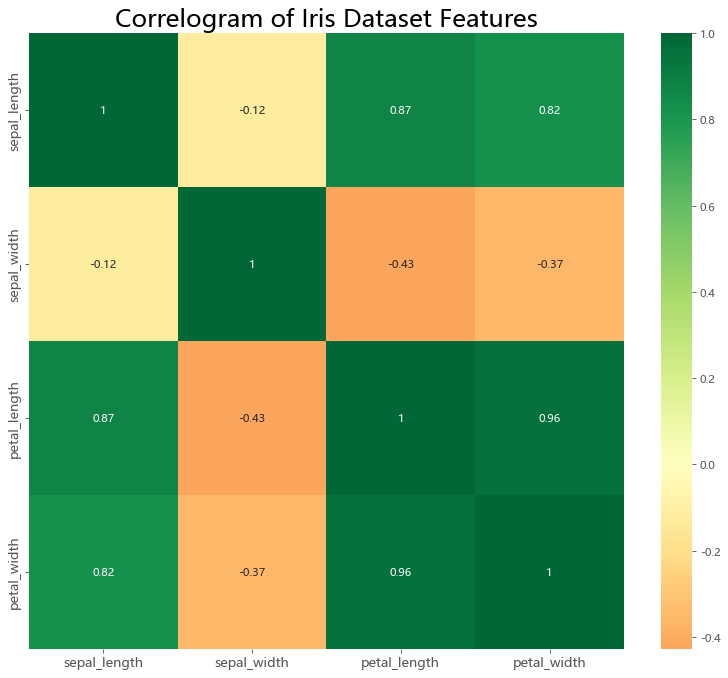

In [11]:
# 相关性热力图
import seaborn as sns
# 只选择数值列进行相关性计算（排除Class列）
numeric_columns = dataset.select_dtypes(include=['float64', 'int64']).columns
correlation = dataset[numeric_columns].corr()

plt.figure(figsize=(12, 10), dpi=80)
sns.heatmap(
    correlation, 
    xticklabels=correlation.columns, 
    yticklabels=correlation.columns, 
    cmap='RdYlGn', 
    center=0, 
    annot=True  # 显示相关系数
)

# 装饰 - 修正标题以匹配数据集
plt.title('Correlogram of Iris Dataset Features', fontsize=22)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()
    

<Figure size 800x640 with 0 Axes>

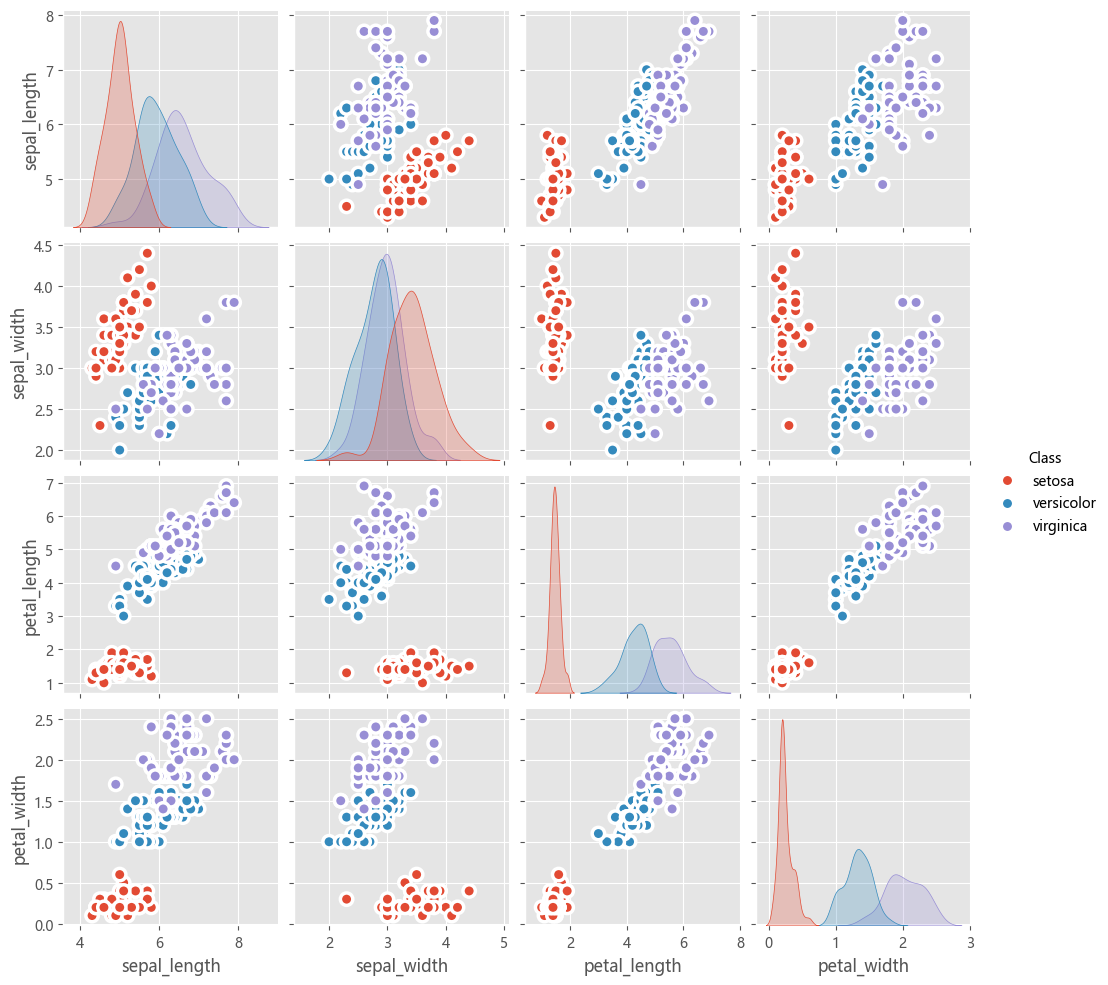

In [9]:
# 配对散点图（散点类型）
import seaborn as sns
plt.figure(figsize=(10, 8), dpi=80)
sns.pairplot(
    dataset, 
    kind="scatter", 
    hue="Class", 
    plot_kws=dict(s=80, edgecolor="white", linewidth=2.5)  # 点的大小、边框色、边框宽度
)
plt.show()

<Figure size 800x640 with 0 Axes>

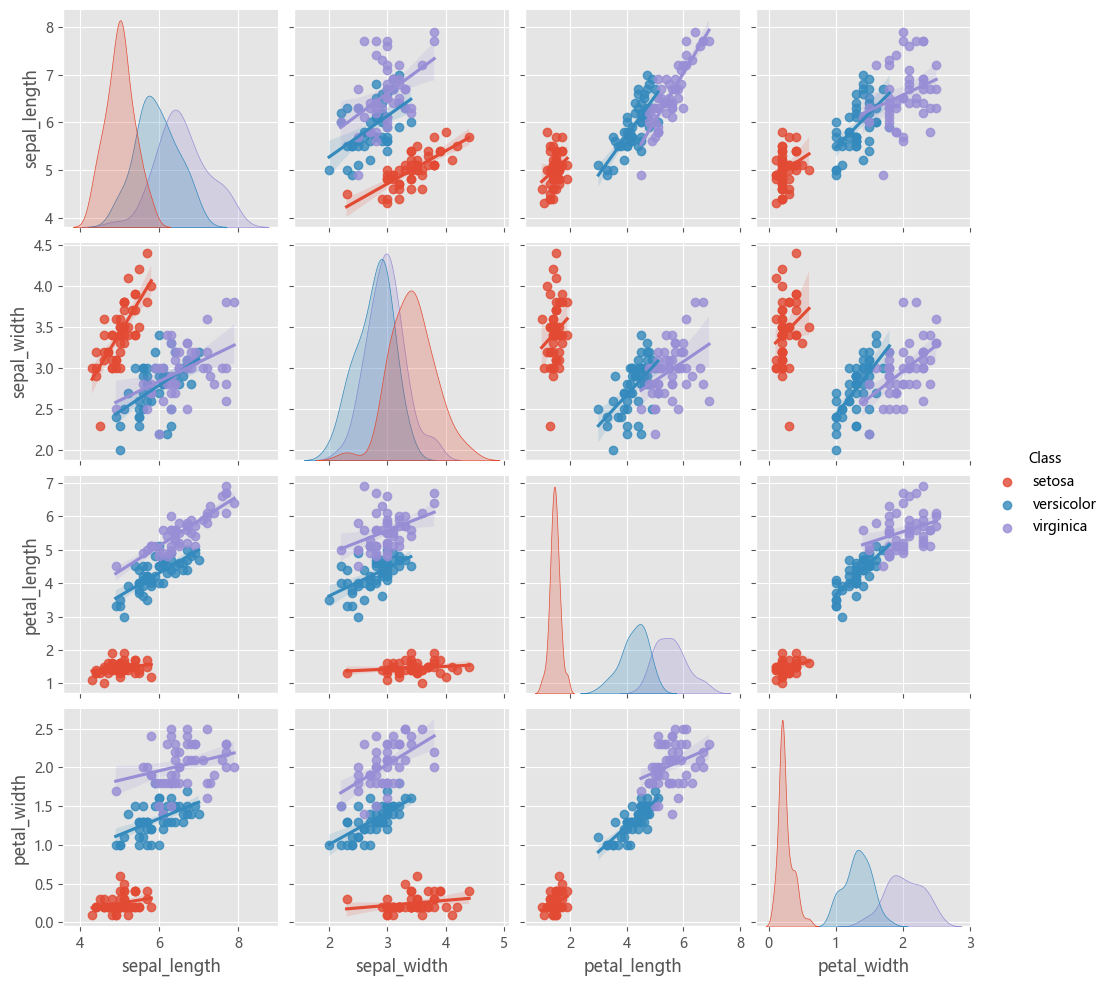

In [10]:
# 配对图（带回归拟合）
plt.figure(figsize=(10, 8), dpi=80)
sns.pairplot(dataset, kind="reg", hue="Class")
plt.show()